### What is being measured?

Concretely, for each junior author:

`n_citing_papers_total_post_award`: number of papers that cite the award paper after it wins

`n_citing_papers_with_junior_author_post_award`: subset of those citing papers where the junior author is on the author list (self‑citations)

`share_self_citing` = `self_citing` / `total_citing`

So the main outcome is: *how much of the award paper’s later citation traffic comes from the junior author themselves?*
- The word "share" means the fraction of all post‑award citing papers that include the junior author as a coauthor.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Greys_r')

BASE = Path(r'B:\Semester 4 UU\thesis-best-paper-trajectories')
DATA_DERIVED = BASE / 'data' / 'derived'
FIG_DIR = BASE / 'figures' / '32_junior_self_cites'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_SELF = DATA_DERIVED / 'junior_awardpaper_self_cites_summary.csv'

df = pd.read_csv(PATH_SELF)
print('Loaded self-citation summary:', df.shape)
df.head()

Loaded self-citation summary: (596, 9)


,award_paper_id,junior_author_id,n_citing_papers_with_junior_author_post_award,n_distinct_citing_papers_with_junior,award_year,award_conference,junior_author_name,n_citing_papers_total_post_award,share_self_citing
0,https://openalex.org/W108223363,https://openalex.org/A5089862531,0,23,2013,ICML,Roi Livni,23,0.0
1,https://openalex.org/W110738662,https://openalex.org/A5102785744,0,44,2007,IJCAI,Maleeha Qazi,44,0.0
2,https://openalex.org/W118378920,https://openalex.org/A5012667159,0,24,2006,SIGMOD,Timothy David Brody,24,0.0
3,https://openalex.org/W146360823,https://openalex.org/A5017775499,0,18,2004,OSDI,Paul Twohey,18,0.0
4,https://openalex.org/W146360823,https://openalex.org/A5056288677,0,18,2004,OSDI,Junfeng Yang,18,0.0


In [2]:
# Basic cleaning / sanity

df['award_conference'] = df['award_conference'].astype(str)
df['award_year'] = pd.to_numeric(df['award_year'], errors='coerce')

df['share_self_citing'] = df['share_self_citing'].fillna(0.0)
df['n_citing_papers_total_post_award'] = pd.to_numeric(
    df['n_citing_papers_total_post_award'], errors='coerce'
)
df = df[df['n_citing_papers_total_post_award'] > 0].copy()

print('After cleaning:', df.shape)
df.describe(include='all').T.head(12)

After cleaning: (596, 9)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
award_paper_id,596,463,https://openalex.org/W2116907335,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junior_author_id,596,596,https://openalex.org/A5089862531,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_citing_papers_with_junior_author_post_award,596.0,NaN,NaN,NaN,3.149329,5.100949,0.0,0.0,1.0,4.0,45.0
n_distinct_citing_papers_with_junior,596.0,NaN,NaN,NaN,295.493289,1311.541294,1.0,46.0,102.0,203.25,28275.0
award_year,596.0,NaN,NaN,NaN,2011.493289,4.984509,2000.0,2008.0,2012.5,2016.0,2018.0
award_conference,596,30,CHI,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junior_author_name,596,596,Roi Livni,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_citing_papers_total_post_award,596.0,NaN,NaN,NaN,295.493289,1311.541294,1.0,46.0,102.0,203.25,28275.0
share_self_citing,596.0,NaN,NaN,NaN,0.036377,0.068801,0.0,0.0,0.008033,0.046067,0.5


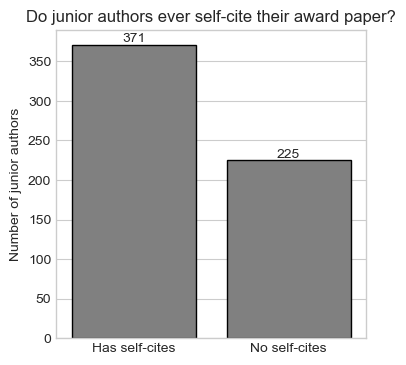

In [3]:
# Any self-citation vs none
df['has_self'] = df['share_self_citing'] > 0

counts = df['has_self'].value_counts().rename(index={False: 'No self-cites',
                                                     True: 'Has self-cites'})

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=counts.index, y=counts.values, color='0.5', edgecolor='black', ax=ax)
ax.set_ylabel('Number of junior authors')
ax.set_xlabel('')
ax.set_title('Do junior authors ever self-cite their award paper?')

for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v}', ha='center', va='bottom')

fig.savefig(FIG_DIR / '32_selfcite_any_vs_none.png', dpi=300, bbox_inches='tight')
plt.show()

This shows how many juniors never self‑cite vs at least once.


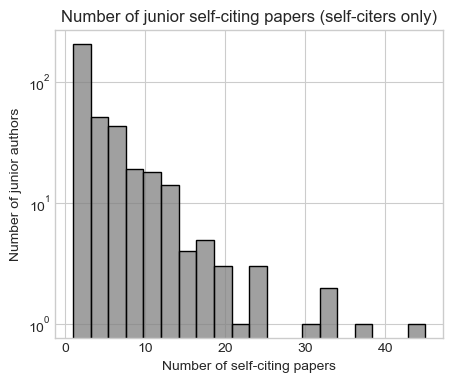

In [4]:
# Distribution of the number of self-citing papers (among self-citers)
df_self = df[df['n_citing_papers_with_junior_author_post_award'] > 0].copy()

fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(df_self['n_citing_papers_with_junior_author_post_award'],
             bins=20, color='0.5', edgecolor='black', ax=ax)
ax.set_title('Number of junior self-citing papers (self-citers only)')
ax.set_xlabel('Number of self-citing papers')
ax.set_ylabel('Number of junior authors')
ax.set_yscale('log')

fig.savefig(FIG_DIR / '32_selfcite_count_hist_self_only.png',
            dpi=300, bbox_inches='tight')
plt.show()

This shows whether self‑citers usually have 1–2 self‑citing papers or more.


The x‑axis is “Number of self‑citing papers” for a junior author (1, 2, 3, …).

The y‑axis is “Number of junior authors”, shown on a log scale, so each step up is 10× more people.

Among juniors who self‑cite at all, almost all do so in only a few papers, and only a tiny minority repeatedly self‑cite their award paper many times.

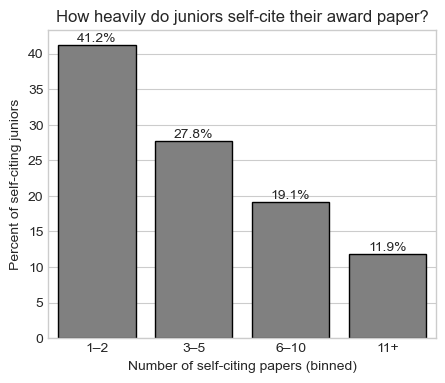

In [11]:
# Categorical bins for number of self-citing papers
bins = [1, 3, 6, 11, df_self['n_citing_papers_with_junior_author_post_award'].max() + 1]
labels = ['1–2', '3–5', '6–10', '11+']

df_self['selfcite_bin'] = pd.cut(
    df_self['n_citing_papers_with_junior_author_post_award'],
    bins=bins, labels=labels, right=False
)

bin_counts = df_self['selfcite_bin'].value_counts().sort_index()
bin_perc = (bin_counts / bin_counts.sum()) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=bin_perc.index, y=bin_perc.values,
            color='0.5', edgecolor='black', ax=ax)
ax.set_ylabel('Percent of self-citing juniors')
ax.set_xlabel('Number of self-citing papers (binned)')
ax.set_title('How heavily do juniors self-cite their award paper?')

for i, v in enumerate(bin_perc.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

fig.savefig(FIG_DIR / '32_selfcite_count_binned_shares.png',
            dpi=300, bbox_inches='tight')
plt.show()

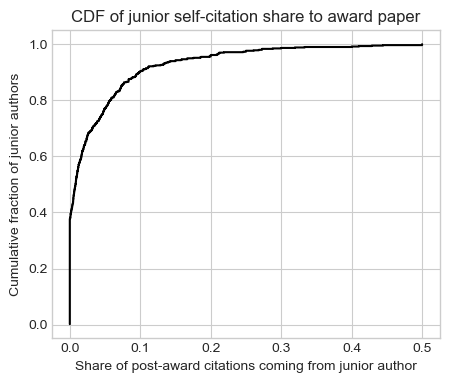

In [6]:
# CDF of self-citation share
import numpy as np

shares = df['share_self_citing'].sort_values().values
n = len(shares)
cdf = (np.arange(1, n + 1) / n)

fig, ax = plt.subplots(figsize=(5, 4))
ax.step(shares, cdf, where='post', color='black')
ax.set_xlabel('Share of post-award citations coming from junior author')
ax.set_ylabel('Cumulative fraction of junior authors')
ax.set_title('CDF of junior self-citation share to award paper')

fig.savefig(FIG_DIR / '32_selfcite_share_cdf.png', dpi=300, bbox_inches='tight')
plt.show()

X% of juniors have self‑citation share below 0.1

On this plot, the x‑axis is **“share of post‑award citations coming from junior author”** and the y‑axis is **“cumulative fraction of junior authors.”**

For almost all junior authors, only a tiny fraction of their award paper’s later citations come from their own follow‑up papers

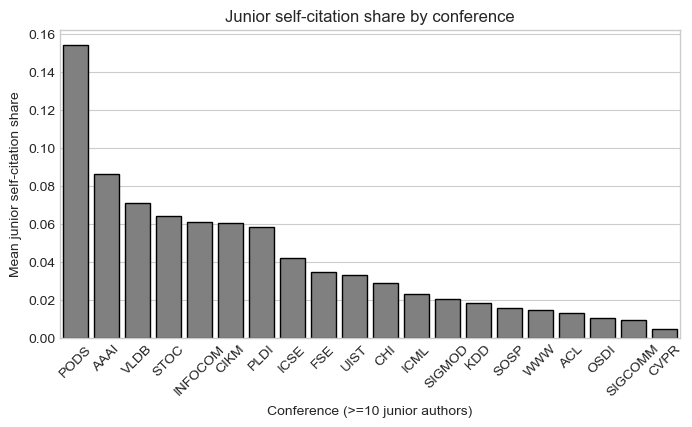

,award_conference,n_junior_authors,mean_share
18,PODS,12,0.154467
0,AAAI,14,0.086375
28,VLDB,18,0.071044
26,STOC,10,0.064284
11,INFOCOM,16,0.060908
3,CIKM,12,0.060382
17,PLDI,26,0.058147
9,ICSE,80,0.042038
6,FSE,47,0.034569
27,UIST,27,0.033100


In [7]:
# Conference-level mean self-citation share (only conferences with >= 10 juniors)
conf_stats = (
    df.groupby('award_conference')
      .agg(n_junior_authors=('junior_author_id', 'nunique'),
           mean_share=('share_self_citing', 'mean'))
      .reset_index()
)

conf_stats_filtered = conf_stats[conf_stats['n_junior_authors'] >= 10].copy()
conf_stats_filtered = conf_stats_filtered.sort_values('mean_share', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=conf_stats_filtered,
            x='award_conference', y='mean_share',
            color='0.5', edgecolor='black', ax=ax)
ax.set_ylabel('Mean junior self-citation share')
ax.set_xlabel('Conference (>=10 junior authors)')
ax.set_title('Junior self-citation share by conference')
ax.tick_params(axis='x', rotation=45)

fig.savefig(FIG_DIR / '32_selfcite_mean_by_conference.png',
            dpi=300, bbox_inches='tight')
plt.show()

conf_stats_filtered

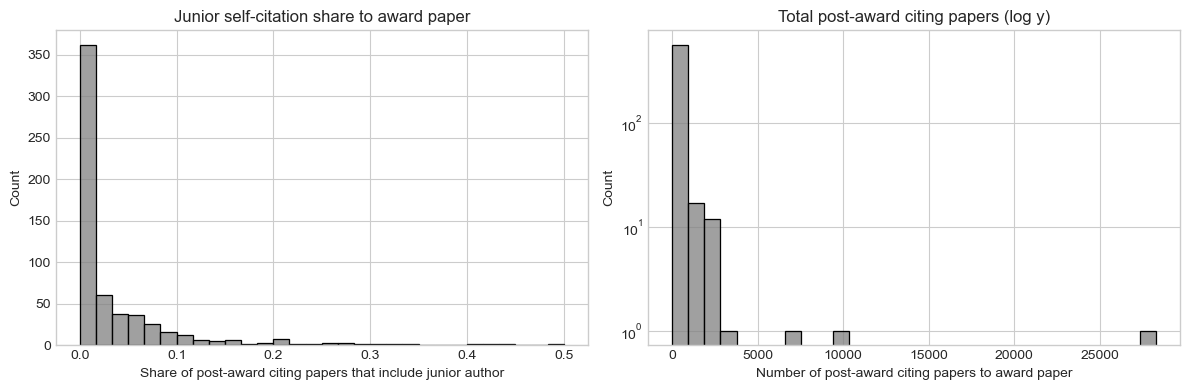

In [4]:
# 1. Overall distribution of junior self-citation share

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: distribution of self-citation share
sns.histplot(df['share_self_citing'], bins=30, ax=axes[0],
             color='0.5', edgecolor='black')
axes[0].set_title('Junior self-citation share to award paper')
axes[0].set_xlabel(
    'Share of post-award citing papers that include junior author'
)

# right: distribution of total post-award citing papers (log y)
sns.histplot(df['n_citing_papers_total_post_award'], bins=30, ax=axes[1],
             color='0.5', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Total post-award citing papers (log y)')
axes[1].set_xlabel('Number of post-award citing papers to award paper')

plt.tight_layout()
fig.savefig(FIG_DIR / '32_selfcite_overall_histograms.png',
            dpi=300, bbox_inches='tight')
plt.show()

Left panel: “Junior self‑citation share to award paper”

- The x‑axis is the share of post‑award citing papers that include the junior author.
- The y‑axis is the number of junior authors at each share level.

*Most juniors contribute almost none of their award paper’s later citations themselves.*

Right panel: “Total post‑award citing papers (log y)”
- The x‑axis is the total number of post‑award citing papers to the award paper.
- The y‑axis is the count of junior authors, on a log scale (10, 100, etc.).

*Award papers vary a lot in overall citation volume, and a few are extremely highly cited.*

In [6]:
# 2. Junior self-citation share by conference: summary table

conf_stats = (
    df.groupby('award_conference', as_index=False)
      .agg(
          n_junior_authors=('junior_author_id', 'count'),
          mean_share=('share_self_citing', 'mean'),
          median_share=('share_self_citing', 'median')
      )
      .sort_values('mean_share', ascending=False)
)

conf_stats.head(15)

,award_conference,n_junior_authors,mean_share,median_share
18,PODS,12,0.154467,0.101085
0,AAAI,14,0.086375,0.033243
28,VLDB,18,0.071044,0.028034
5,FOCS,9,0.068472,0.016216
26,STOC,10,0.064284,0.025517
11,INFOCOM,16,0.060908,0.008309
3,CIKM,12,0.060382,0.060754
17,PLDI,26,0.058147,0.018250
24,SODA,5,0.053371,0.016129
9,ICSE,80,0.042038,0.012692


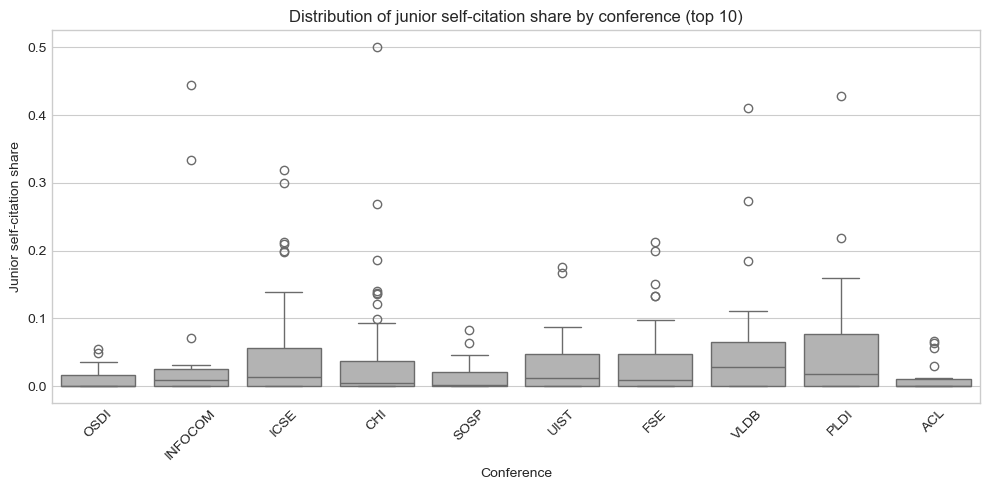

In [7]:
# 2. Junior self-citation share by conference: boxplot (top 10)

top_confs = df['award_conference'].value_counts().head(10).index
df_top = df[df['award_conference'].isin(top_confs)].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_top,
    x='award_conference',
    y='share_self_citing',
    color='0.7'  # light grey fill
)
plt.xticks(rotation=45)
plt.ylabel('Junior self-citation share')
plt.xlabel('Conference')
plt.title('Distribution of junior self-citation share by conference (top 10)')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_by_conference_boxplot.png',
            dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# 3. Junior self-citation share over award year: summary table

year_stats = (
    df.groupby('award_year', as_index=False)
      .agg(
          mean_share=('share_self_citing', 'mean'),
          median_share=('share_self_citing', 'median'),
          n_junior_authors=('junior_author_id', 'count')
      )
)

year_stats.head()

,award_year,mean_share,median_share,n_junior_authors
0,2000,0.007244,0.001622,10
1,2001,0.013571,0.000000,14
2,2002,0.013703,0.008671,3
3,2003,0.020808,0.007246,21
4,2004,0.033913,0.006217,26


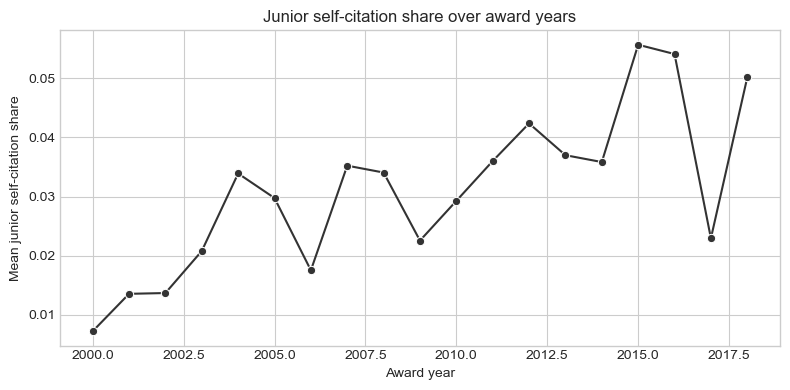

In [9]:
# 3. Junior self-citation share over award year: line plot

plt.figure(figsize=(8, 4))
sns.lineplot(data=year_stats, x='award_year', y='mean_share',
             color='0.2', marker='o')
plt.ylabel('Mean junior self-citation share')
plt.xlabel('Award year')
plt.title('Junior self-citation share over award years')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_over_time_mean.png',
            dpi=300, bbox_inches='tight')
plt.show()

The x‑axis is award year (2000–2018).

The y‑axis is the mean self‑citation share for juniors who won in that year (average over all junior authors of award papers from that year).

*Over time, junior self‑citation shares wiggle around a bit and may edge up slightly, but in every award year the average junior still supplies only a few percent of their award paper’s citations.*

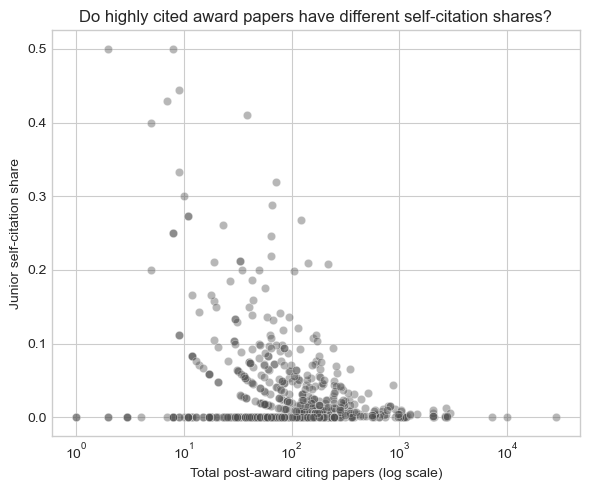

In [10]:
# 4. Relationship between self-citation share and citation impact size

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x='n_citing_papers_total_post_award',
    y='share_self_citing',
    color='0.3',
    alpha=0.4,
)
plt.xscale('log')
plt.xlabel('Total post-award citing papers (log scale)')
plt.ylabel('Junior self-citation share')
plt.title('Do highly cited award papers have different self-citation shares?')
plt.tight_layout()
plt.savefig(FIG_DIR / '32_selfcite_vs_total_citations_scatter.png',
            dpi=300, bbox_inches='tight')
plt.show()

Each dot is a junior author–award paper pair.

The x‑axis (log scale) is the total number of post‑award citing papers to that award paper.

The y‑axis is the junior’s self‑citation share for that award paper.

*Award papers with many citations almost never rely on junior self‑citations, while high self‑citation shares mainly occur for award papers that are only modestly cited overall.*

---

Summary:

The average share of self‑citations is about 3.6%.

The median is around 0.8%.

The 75th percentile is about 4.6%, and the maximum is 50%.

*It shows that junior authors’ self‑citations to their best‑paper award articles are usually a very small fraction of total post‑award citations, with modest venue‑level differences and a long but sparse right tail.*